<a href="https://colab.research.google.com/github/jiq-star/UTS-DATMN-2304020029/blob/main/uts_datmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. persiapan data

In [ ]:
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier

In [ ]:
data_training = pd.read_csv('/content/data_training.csv')
data_testing = pd.read_csv('/content/data_testing.csv')

data_training

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [22]:
data_testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


In [ ]:
X = data_training.drop(columns=['quality', 'Id'])
y = data_training['quality']

model klasifikasi

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

In [ ]:
model.fit(X, y)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

simpan model

In [ ]:
joblib.dump(model, 'model_klasifikasi_wine.pkl')

['model_klasifikasi_wine.pkl']

2. PEMBERSIHAN DATA

In [ ]:
print("Missing Values Data Training :")
print(data_training.isnull().sum())


Missing Values Data Training :
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
print("Missing Values Data Testing :")
print(data_testing.isnull().sum())

Missing Values Data Testing :
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Berdasarkan hasil pengecekan missing values, seluruh fitur pada dataset training dan dataset testing memiliki nilai 0. Hal ini menunjukkan bahwa tidak terdapat data yang hilang (missing values), sehingga tidak diperlukan proses imputasi maupun penghapusan data.

FEATURE SCALLING

In [ ]:
from sklearn.preprocessing import StandardScaler
# Memisahkan fitur
X = data_training.drop(columns=['quality', 'Id'])
X_testing = data_testing.drop(columns=['Id'])

# Membuat scaler
scaler = StandardScaler()

# Fit dan transform data training
X_scaled = scaler.fit_transform(X)
X_testing_scaled = scaler.transform(X_testing)

3. Pembuatan Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

TRAINING MODEL

In [ ]:
model.fit(X_scaled, y)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

EVALUASI MODEL

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Prediksi data training
y_pred = model.predict(X_scaled)

# Menghitung akurasi
accuracy = accuracy_score(y, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


Nilai akurasi yang diperoleh dari model Random Forest Classifier adalah sebesar 1.0 atau 100%. Hasil tersebut menunjukkan bahwa model mampu memprediksi seluruh data training dengan sangat baik tanpa adanya kesalahan prediksi. Dengan akurasi yang sempurna, dapat disimpulkan bahwa model berhasil mempelajari pola dari dataset pelatihan secara optimal.

CONFUSION MATRIX

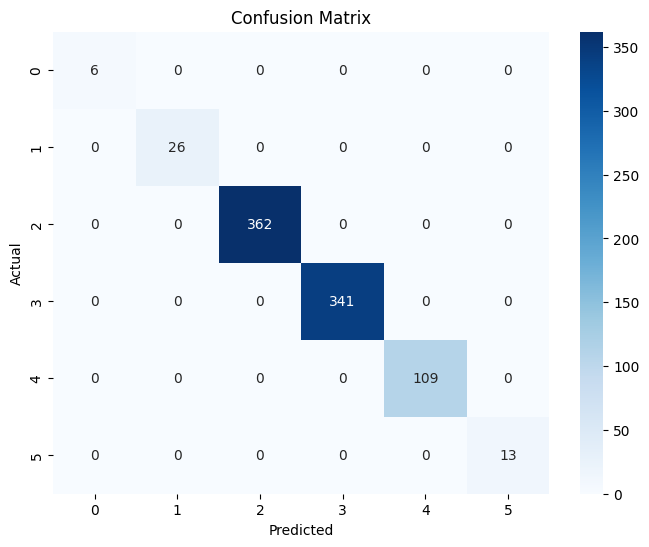

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

Berdasarkan hasil confusion matrix, seluruh data berhasil diprediksi sesuai dengan kelas aslinya. Hal ini terlihat dari seluruh nilai yang berada pada diagonal utama matriks, sedangkan tidak terdapat nilai pada bagian luar diagonal. Artinya, model tidak mengalami kesalahan klasifikasi pada setiap kelas quality, mulai dari quality 3 hingga quality 8.

In [ ]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



Hasil classification report menunjukkan bahwa nilai precision, recall, dan f1-score pada seluruh kelas memiliki nilai 1.00. Hal ini menandakan bahwa model memiliki performa yang sangat baik dalam mengenali masing-masing kelas pada dataset training. Selain itu, nilai weighted average dan macro average yang juga mencapai 1.00 menunjukkan bahwa performa model sangat konsisten pada seluruh kelas data.

4. PREDIKSI DATA

In [ ]:
prediksi_quality = model.predict(X_testing_scaled)

In [20]:
hasil_prediksi = pd.DataFrame({
    'Id': data_testing['Id'],
    'quality': prediksi_quality
})

print()
display(hasil_prediksi)

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,5


Kolom Id digunakan sebagai identitas setiap data wine pada dataset testing, sedangkan kolom quality merupakan hasil prediksi kualitas wine yang dihasilkan oleh model klasifikasi. Berdasarkan hasil yang ditampilkan, model memprediksi beberapa nilai quality seperti 5, 6, dan 7 pada data testing. Hal ini menunjukkan bahwa model mampu mengklasifikasikan kualitas wine sesuai pola yang telah dipelajari dari dataset training.

In [21]:
hasil_prediksi.to_csv('hasilprediksi_029.csv', index=False)